In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Web_data.csv")
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [6]:
df.columns = df.iloc[0]

In [7]:
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [8]:
df = df.drop(index = 0).reset_index(drop = True)
df.columns = ["channel group","DateHour","Users","Sessions","Engaged Sessions","Average engagement time per session","Engaged sessions per user","Events per session","Engagement rate","Event count"]
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged Sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


Change datatype object to datatime for datehour column

In [10]:
df["DateHour"] = pd.to_datetime(df["DateHour"], format='%Y%m%d%H', errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   object        
 3   Sessions                             3182 non-null   object        
 4   Engaged Sessions                     3182 non-null   object        
 5   Average engagement time per session  3182 non-null   object        
 6   Engaged sessions per user            3182 non-null   object        
 7   Events per session                   3182 non-null   object        
 8   Engagement rate                      3182 non-null   object        
 9   Event count                          3182 non-null   object        
dtypes: datetime6

In [12]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [13]:
numeric_col = df.columns.drop(["channel group","DateHour"])
df[numeric_col] = df[numeric_col].apply(pd.to_numeric, errors= 'coerce')
df["Hour"] = df["DateHour"].dt.hour

In [14]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged Sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

Sessions and User Over time

In [16]:
sns.set(style="whitegrid")

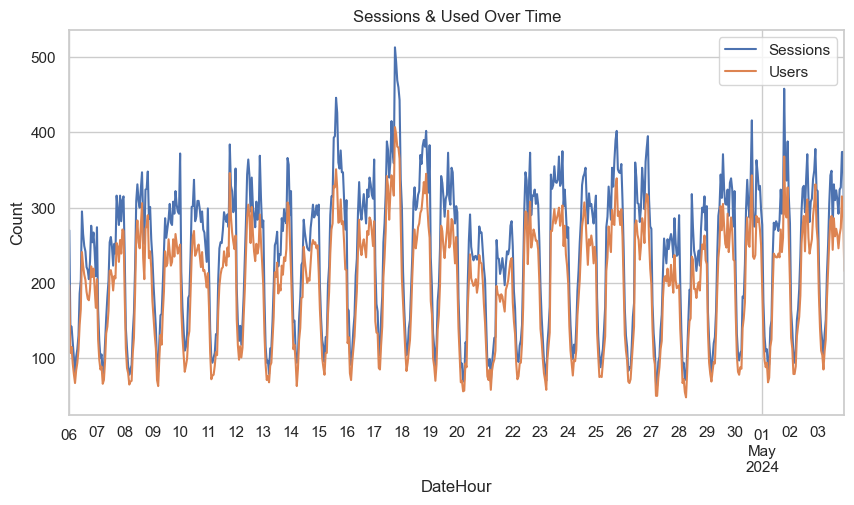

In [17]:
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions & Used Over Time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.savefig("sessions and used over time.png",dpi=2000,bbox_inches="tight")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_9208\929248212.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df , x="channel group", y="Users", estimator=np.sum,palette="viridis")


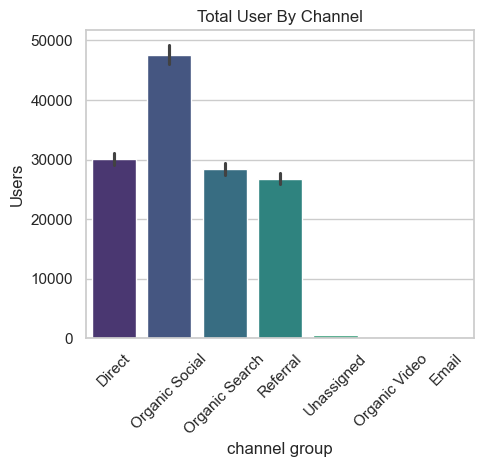

In [18]:
plt.figure(figsize = (5,4))
sns.barplot(data=df , x="channel group", y="Users", estimator=np.sum,palette="viridis")
plt.title("Total User By Channel")
plt.xticks(rotation=45)
plt.savefig("total user by channel.png",dpi=2000,bbox_inches="tight")
plt.show()

Average Angagement time by channel

C:\Users\hp\AppData\Local\Temp\ipykernel_9208\3686070007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df , x = "channel group",y = "Average engagement time per session" ,palette = "magma")


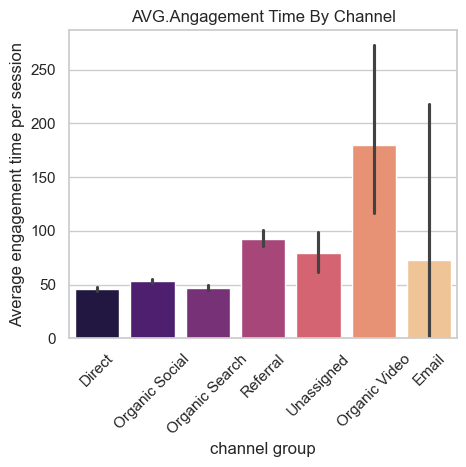

In [19]:
plt.figure(figsize = (5,4))
sns.barplot(data = df , x = "channel group",y = "Average engagement time per session" ,palette = "magma")
plt.title("AVG.Angagement Time By Channel")
plt.xticks(rotation=45)
plt.savefig("avg angagement time by channel.png",dpi=2000,bbox_inches="tight")
plt.show()

Engagement rate distribution by channel group

C:\Users\hp\AppData\Local\Temp\ipykernel_9208\1901652388.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df , x = "channel group", y = "Engagement rate", palette="coolwarm")


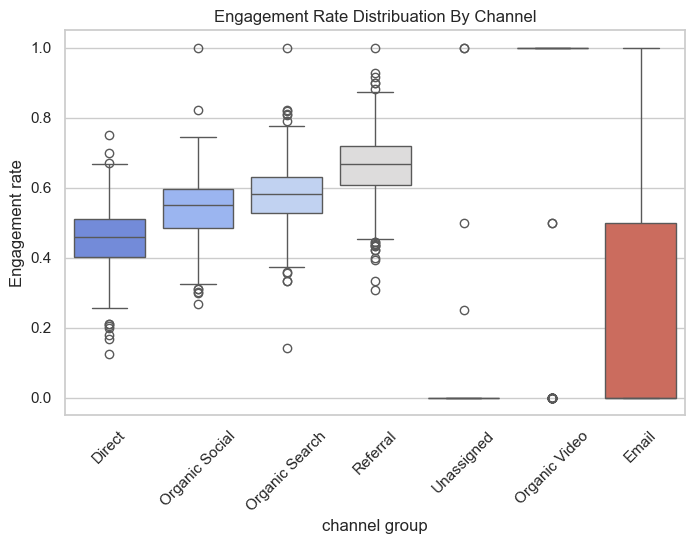

In [20]:
plt.figure(figsize = (8,5))
sns.boxplot(data = df , x = "channel group", y = "Engagement rate", palette="coolwarm")
plt.title("Engagement Rate Distribuation By Channel")
plt.xticks(rotation = 45)
plt.savefig("engagement rate distribuation bt channel.png",dpi=2000,bbox_inches="tight")
plt.show()

Engaged vs non-engaged sessions

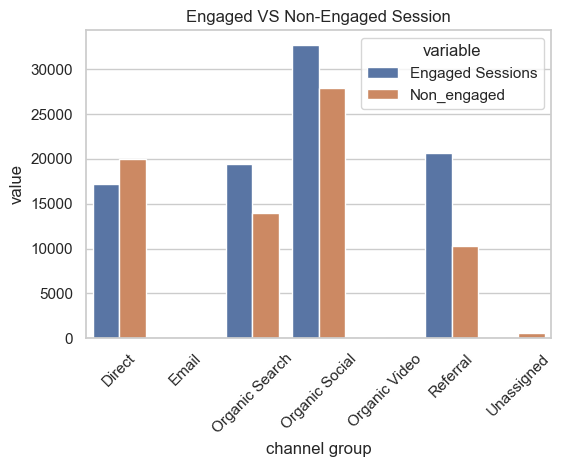

In [21]:
session_df = df.groupby("channel group")[["Sessions","Engaged Sessions"]].sum().reset_index()
session_df["Non_engaged"] = session_df["Sessions"] - session_df["Engaged Sessions"]
session_df_melted = session_df.melt(id_vars = "channel group",value_vars = ["Engaged Sessions","Non_engaged"])

plt.figure(figsize = (6,4))
sns.barplot(data = session_df_melted , x = "channel group", y = "value" , hue = "variable")
plt.title("Engaged VS Non-Engaged Session")
plt.xticks(rotation=45)
plt.savefig("engaged vs non-engaged session.png",dpi=2000,bbox_inches="tight")
plt.show()

traffic by hour and channel

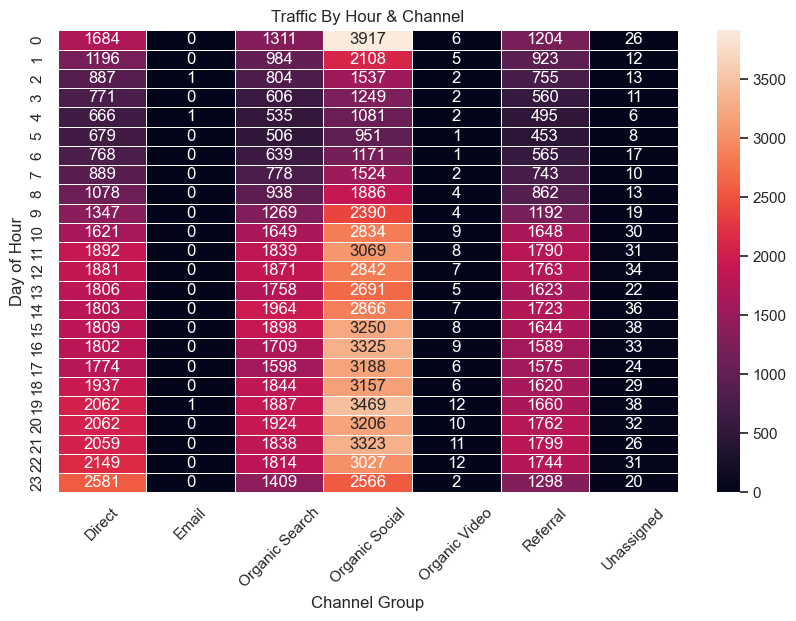

In [22]:
heatmap_data = df.groupby(["Hour","channel group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize = (10,6))
sns.heatmap(data = heatmap_data, linewidths=.5,annot=True,fmt='.0f')
plt.title("Traffic By Hour & Channel")
plt.xlabel("Channel Group")
plt.xticks(rotation = 45)
plt.ylabel("Day of Hour")
plt.savefig("traffic by hour and channel.png",dpi=2000,bbox_inches="tight")
plt.show()

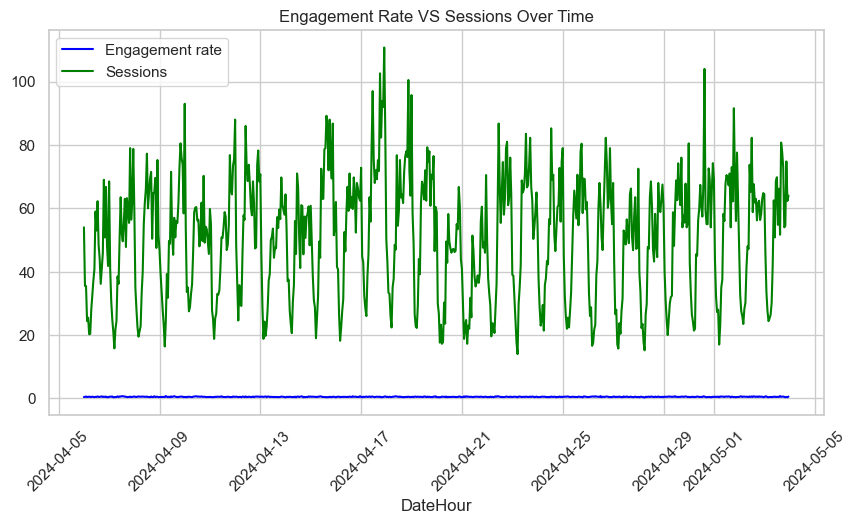

In [23]:
df_plot = df.groupby("DateHour")[["Engagement rate","Sessions"]].mean().reset_index()

plt.figure(figsize = (10,5))
plt.plot(df_plot["DateHour"], df_plot["Engagement rate"],label = "Engagement rate" , color = "blue")
plt.plot(df_plot["DateHour"], df_plot["Sessions"],label = "Sessions", color = "green")
plt.title("Engagement Rate VS Sessions Over Time")
plt.xticks(rotation = 45)
plt.xlabel("DateHour")
plt.legend()
plt.savefig("engagement rate vs sessions over time.png",dpi=2000,bbox_inches="tight")
plt.show()

CREATED BY PRAJWAL KHANDARE